
# Concrete Crack Detection (Bounding Box) using YOLO26

This notebook demonstrates how to train a YOLO26 model for detecting concrete cracks, evaluate its performance, and deploy it as a Gradio web application.



## Install Ultralytics

First, we need to install the `ultralytics` library, which provides the YOLO (You Only Look Once) model functionalities. The `-q` flag ensures a quiet installation.


In [ ]:
!pip install -q ultralytics


## Download Dataset

Next, we download the dataset for training the crack detection model from Kaggle Hub. The dataset used is "roads-and-bridges-cracks-yolov8-format". The `path` variable will store the location of the downloaded dataset.


In [ ]:
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("danishghaffar786/roads-and-bridges-cracks-yolov8-format")

print("Dataset downloaded to:", path)

100%|██████████| 251M/251M [00:02<00:00, 89.1MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/danishghaffar786/roads-and-bridges-cracks-yolov8-format/versions/1



## Train YOLOv8 Model

We initialize a pre-trained `yolov8n.pt` (nano version) model and then train it using our downloaded dataset. The training process is configured with 50 epochs and an image size of 640x640 pixels.


In [ ]:
from ultralytics import YOLO

# load pre-trained model
model = YOLO("yolov8n.pt")

# train the model
model.train(
    data=f"{path}/data.yaml",
    epochs=50,
    imgsz=640,
)



Ultralytics 8.4.101 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/danishghaffar786/roads-and-bridges-cracks-yolov8-format/versions/1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d721d2203e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Ultralytics Automatically downloaded the YOLO26n instead of YOLOv8


## Export Model to ONNX

After training, we export the `best.pt` weights of the model to the ONNX (Open Neural Network Exchange) format. ONNX is an open standard designed to represent machine learning models, which allows for easier deployment across different platforms and hardware.


In [ ]:
# Export the trained weights
model.export(format="onnx")

Ultralytics 8.4.101 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train-3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 288ms
Prepared 4 packages in 1.86s
Installed 4 packages in 275ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming wi

'/content/runs/detect/train-3/weights/best.onnx'


## Download Trained Model

This cell provides functionality to download the exported `best.onnx` model file directly to your local machine. This allows you to use the trained model outside of this Colab environment.


In [ ]:
from google.colab import files

# The trained model is typically saved as 'best.onnx' in the run directory.
# Based on the training output, the save directory was '/content/runs/detect/train-3'.
model_path = '/content/runs/detect/train-3/weights/best.onnx'

try:
    files.download(model_path)
    print(f"Downloading {model_path} to your local machine.")
except Exception as e:
    print(f"Error downloading the model: {e}")
    print("Please ensure the file path is correct and the training completed successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## Visualize Training Results

During training, Ultralytics generates various plots to visualize the model's performance and training progress. This section displays key evaluation plots like `results.png` (showing loss and mAP over epochs), `confusion_matrix.png`, and `F1_curve.png`.


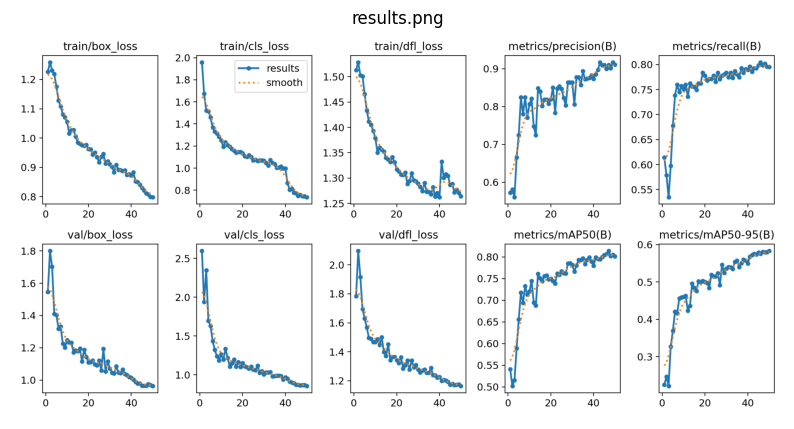

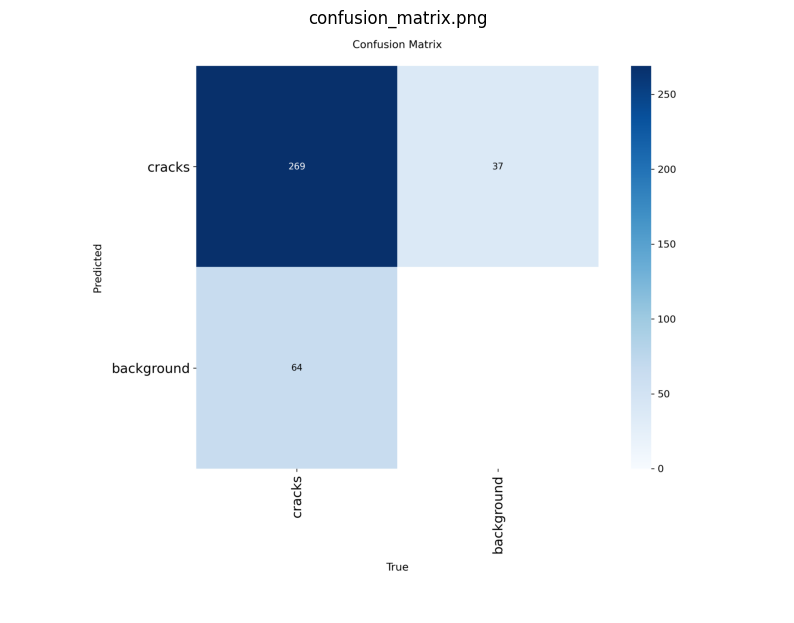

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Path to the results directory (based on your logs: train-3)
results_dir = '/content/runs/detect/train-3'

# List of evaluation plots to view
plots = ['results.png', 'confusion_matrix.png', 'F1_curve.png']

for plot in plots:
    plot_path = os.path.join(results_dir, plot)
    if os.path.exists(plot_path):
        plt.figure(figsize=(10, 8))
        img = mpimg.imread(plot_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(plot)
        plt.show()


## Validate Model Performance

This cell performs a final validation of the trained model using the `best.pt` weights and the validation split of the dataset. It prints important metrics such as mAP50 (mean Average Precision at an IoU threshold of 0.5) and mAP50-95 (mean Average Precision across IoU thresholds from 0.5 to 0.95), which are standard metrics for object detection tasks.


In [ ]:
# Validate the model using the best weights generated
metrics = model.val(data=f"{path}/data.yaml")

# Print key metrics
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.101 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2714.0±893.3 MB/s, size: 85.3 KB)
val: Scanning /root/.cache/kagglehub/datasets/danishghaffar786/roads-and-bridges-cracks-yolov8-format/versions/1/valid/labels.cache... 288 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 288/288 86.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 238, len(boxes) = 333. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 3.1it/s 5.7s
                   all        288        333      0.911      0.796      0.801      0.583
Speed: 5.2ms preprocess, 4.9ms inference, 0.0ms lo


## Deploy with Gradio UI

Finally, we create a simple web interface using `Gradio` to interact with our trained crack detection model. You can upload an image, adjust the confidence threshold, and the application will display the image with detected cracks and a status message. This demonstrates how to deploy the ONNX model for real-time inference.


In [ ]:
import gradio as gr
from ultralytics import YOLO
import cv2

# Load model weights
# model = YOLO('/content/runs/detect/train-3/weights/best.pt')

# Load the optimized ONNX model instead of the heavy .pt file
model = YOLO('/content/runs/detect/train-3/weights/best.onnx', task='detect')

def predict_cracks(image, conf_threshold):
    # Run inference
    results = model(image, conf=conf_threshold)
    res = results[0]

    # Check if any bounding boxes were detected
    if len(res.boxes) == 0:
        status_text = "No crack detected"
        # Return the original image (converted to RGB) and the status message
        return image, status_text
    else:
        status_text = f"Success! Detected {len(res.boxes)} crack(s)."
        annotated_image = res.plot()  # Returns BGR numpy array
        annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
        return annotated_image_rgb, status_text

# Build interface with an additional text output
demo = gr.Interface(
    fn=predict_cracks,
    inputs=[
        gr.Image(type="numpy", label="Upload Concrete Image"),
        gr.Slider(minimum=0.05, maximum=1.0, value=0.25, step=0.05, label="Confidence Threshold")
    ],
    outputs=[
        gr.Image(type="numpy", label="Detected Cracks"),
        gr.Textbox(label="Status") # This will display the text message
    ],
    title="Concrete Crack Detection UI",
    description="Upload a photo. If no cracks are found, the status will update accordingly."
)

demo.launch(share=True, inline=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5b650d37698312bbc1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Model Output 1

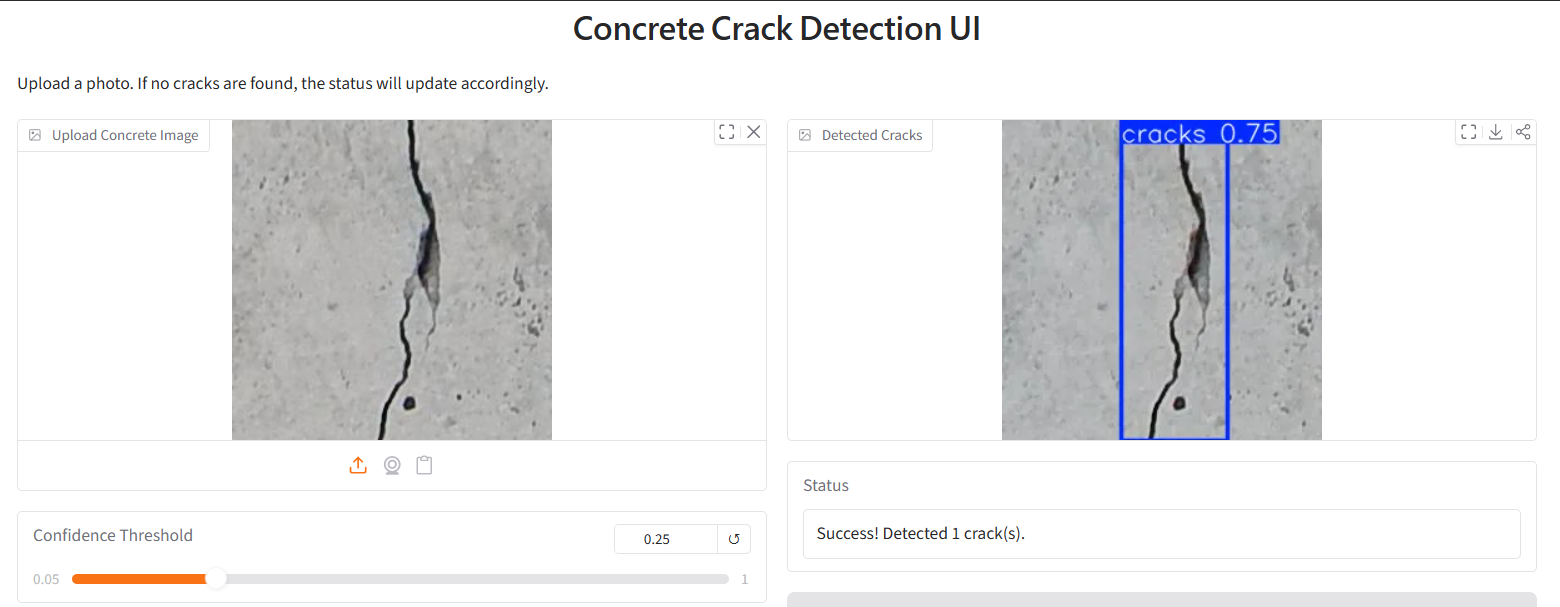

## Model Output 2

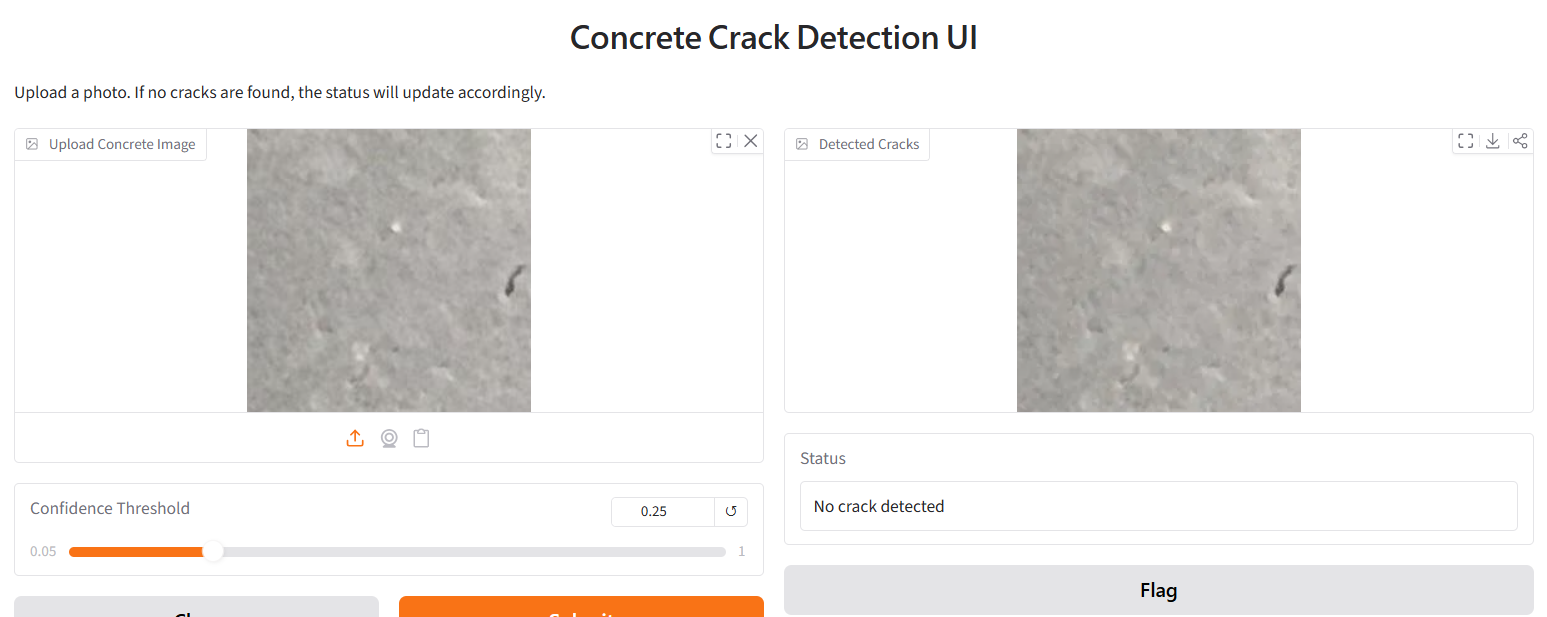

## Model Output 3

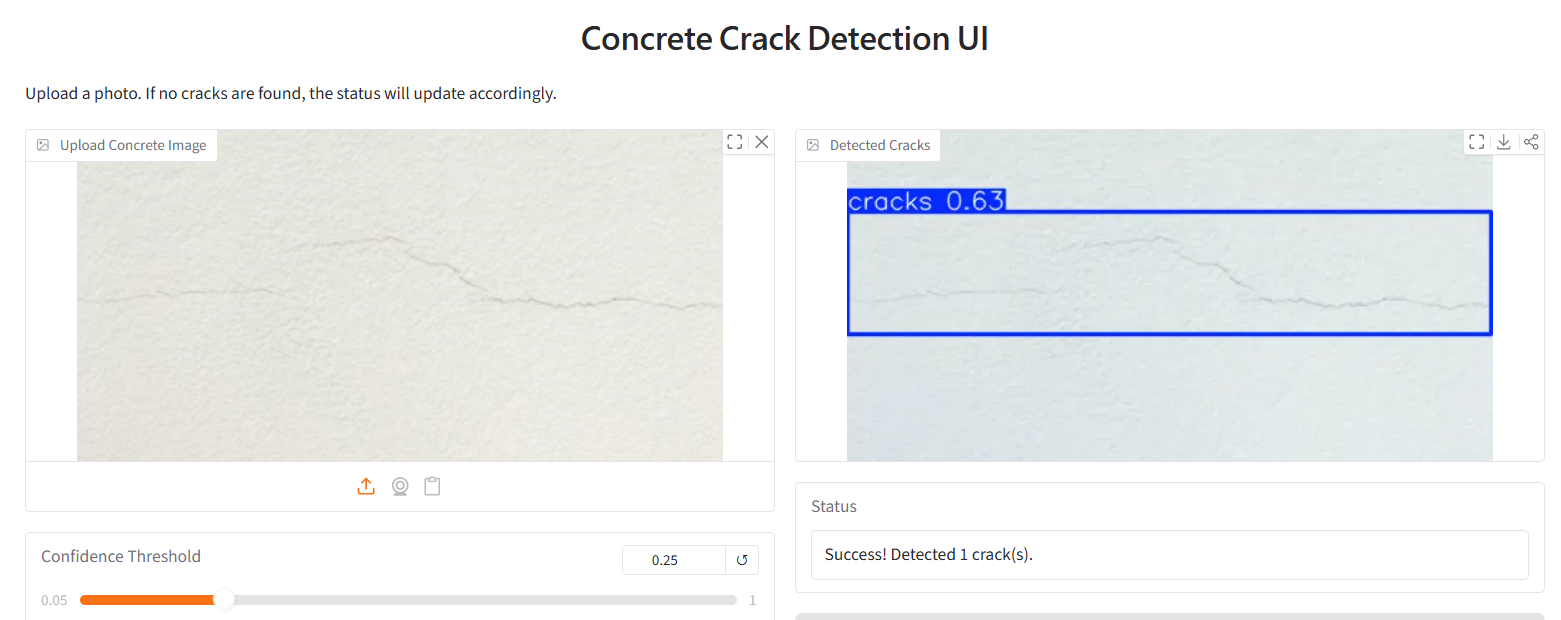